In [1]:
import os
print(os.getcwd())

/home/ismael/Documentos/Finanza_flutter/IA_HUGO/data_set2


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("bank.xlsx")

# limpiar columnas basura
df = df.drop(columns=['.', 'CHQ.NO.'])

# rellenar nulls
df['WITHDRAWAL AMT'] = df['WITHDRAWAL AMT'].fillna(0)
df['DEPOSIT AMT'] = df['DEPOSIT AMT'].fillna(0)

# crear variable clave
df['amount'] = df['DEPOSIT AMT'] - df['WITHDRAWAL AMT']

df.head()

,Account No,DATE,TRANSACTION DETAILS,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT,amount
0,409000611074',2017-06-29,TRF FROM Indiaforensic SERVICES,2017-06-29,0.0,1000000.0,1000000.0,1000000.0
1,409000611074',2017-07-05,TRF FROM Indiaforensic SERVICES,2017-07-05,0.0,1000000.0,2000000.0,1000000.0
2,409000611074',2017-07-18,FDRL/INTERNAL FUND TRANSFE,2017-07-18,0.0,500000.0,2500000.0,500000.0
3,409000611074',2017-08-01,TRF FRM Indiaforensic SERVICES,2017-08-01,0.0,3000000.0,5500000.0,3000000.0
4,409000611074',2017-08-16,FDRL/INTERNAL FUND TRANSFE,2017-08-16,0.0,500000.0,6000000.0,500000.0


In [6]:
# usar fecha como índice
df = df.set_index('DATE')

# agrupar por día
df_daily = df['amount'].resample('D').sum()

df_daily.head()

DATE
2015-01-01    2004999.00
2015-01-02   -3034436.18
2015-01-03     748160.00
2015-01-04          0.00
2015-01-05     678020.00
Freq: D, Name: amount, dtype: float64

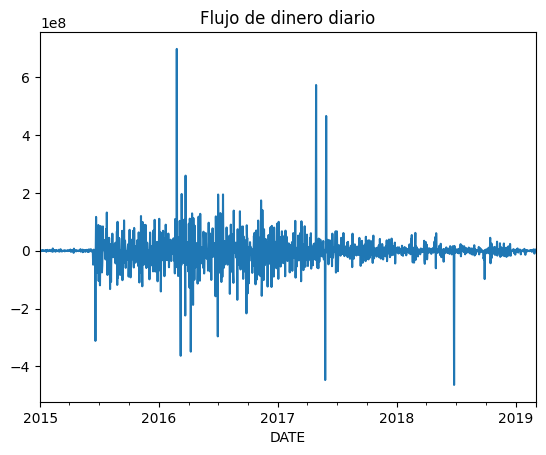

In [7]:
df_daily.plot()
plt.title("Flujo de dinero diario")
plt.show()

In [8]:
from statsmodels.tsa.arima.model import ARIMA

# modelo
model = ARIMA(df_daily, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 amount   No. Observations:                 1525
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -29265.297
Date:                Thu, 16 Apr 2026   AIC                          58536.595
Time:                        00:39:39   BIC                          58552.582
Sample:                    01-01-2015   HQIC                         58542.546
                         - 03-05-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1394      0.024     -5.912      0.000      -0.186      -0.093
ma.L1         -0.9992      0.008   -119.536      0.000      -1.016      -0.983
sigma2      3.654e+15    1.5e-18   2.44e+33      0.0

In [9]:
forecast = model_fit.forecast(steps=10)

print(forecast)

2019-03-06   -1.443963e+06
2019-03-07   -1.144236e+06
2019-03-08   -1.186019e+06
2019-03-09   -1.180195e+06
2019-03-10   -1.181007e+06
2019-03-11   -1.180893e+06
2019-03-12   -1.180909e+06
2019-03-13   -1.180907e+06
2019-03-14   -1.180907e+06
2019-03-15   -1.180907e+06
Freq: D, Name: predicted_mean, dtype: float64


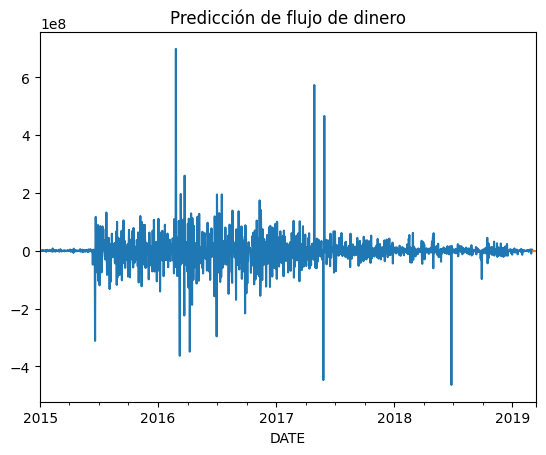

In [10]:
df_daily.plot()
forecast.plot()

plt.title("Predicción de flujo de dinero")
plt.show()

Se procesaron las transacciones bancarias para obtener una serie temporal diaria del flujo de dinero.

Se utilizó el modelo ARIMA para analizar el comportamiento de la serie y generar predicciones futuras.

Este modelo permite identificar patrones en los datos históricos y estimar valores futuros del flujo financiero